In [ ]:
#Data Loading
import pandas as pd
import numpy as np

df = pd.read_csv("Invistico_Airline.csv")

#Displaying the first and last row of the dataset
print(f"The first row in the dataset is: {df.head(1)}")
print(f"The last row in the dataset is: {df.tail(1)}")

#Checking the number of rows and columns in the dataset
print(f"The number of rows and columns in the dataset is: {df.shape}")

#Identifying column names
print(f"The column names in the dataset are: {df.columns.tolist()}")

#Checking data types
print(f"The data types of each column in the dataset are: {df.dtypes}")

#Identifying any missing values in the dataset
print(f"The number of missing values in each column is: :\n{df.isnull().sum()}")

#Identifying any duplicate values in the dataset
print(f"The number of duplicate values in the dataset is: {df.duplicated().sum()}")

#Describing the dataset statistically
print(f"The statistical description of the dataset is:\n{df.describe()}")

The first row in the dataset is:   satisfaction  Gender   Customer Type  Age   Type of Travel Class  \
0    satisfied  Female  Loyal Customer   65  Personal Travel   Eco   

   Flight Distance  Seat comfort  Departure/Arrival time convenient  \
0              265             0                                  0   

   Food and drink  ...  Online support  Ease of Online booking  \
0               0  ...               2                       3   

   On-board service  Leg room service  Baggage handling  Checkin service  \
0                 3                 0                 3                5   

   Cleanliness  Online boarding  Departure Delay in Minutes  \
0            3                2                           0   

   Arrival Delay in Minutes  
0                       0.0  

[1 rows x 23 columns]
The last row in the dataset is:         satisfaction  Gender      Customer Type  Age   Type of Travel Class  \
129879  dissatisfied  Female  disloyal Customer   38  Personal Travel   Eco 

In [ ]:
#Data Cleaning
import pandas as pd
df = pd.read_csv("Invistico_Airline.csv")
#Removing duplicate values to ensure there is no bias in the analysis
df = df.drop_duplicates()

#Renaming the columns to ensure consistency and avoid any errors during analysis
df.columns = df.columns.str.strip().str.lower().str.replace(" ", "_")

#Creating a new column to calculate the total delay caused for each flight
df['total_delay'] = df['departure_delay_in_minutes'] + df['arrival_delay_in_minutes']

#To ensure incomplete records do not affect the accuracy of the analysis.
#check for missing values
df = df.dropna()

# The following lines are redundant if df.dropna() is applied to the whole dataframe first.
df['arrival_delay_in_minutes'] = df['arrival_delay_in_minutes'].fillna(df['arrival_delay_in_minutes'].median())
df['arrival_delay_in_minutes'].isnull().sum()

#check for outliers
df[['age', 'flight_distance', 'departure_delay_in_minutes',
    'arrival_delay_in_minutes', 'total_delay']].describe()

#saving the cleaned dataset to a new CSV file for future analysis
df.to_csv("Cleaned_Invistico_Airline.csv", index=False)

#view the cleaned data
df.head()
# Check for remaining missing values
df.isnull().sum()

# Confirm the new column exists
df.columns.tolist()







['satisfaction',
 'gender',
 'customer_type',
 'age',
 'type_of_travel',
 'class',
 'flight_distance',
 'seat_comfort',
 'departure/arrival_time_convenient',
 'food_and_drink',
 'gate_location',
 'inflight_wifi_service',
 'inflight_entertainment',
 'online_support',
 'ease_of_online_booking',
 'on-board_service',
 'leg_room_service',
 'baggage_handling',
 'checkin_service',
 'cleanliness',
 'online_boarding',
 'departure_delay_in_minutes',
 'arrival_delay_in_minutes',
 'total_delay']

In [47]:
#Data analysis
import pandas as pd

# Load the cleaned dataset
df = pd.read_csv("/content/Cleaned_Invistico_Airline (1).csv")

#Count customer satisfaction levels
analysis = df['satisfaction'].value_counts()
display(analysis)

#How many customers were satisfied and travelled in Business Class?
business_satisfied = df[
    (df['class'] == 'Business') &
    (df['satisfaction'] == 'satisfied')
]
business_satisfied.head()
len(business_satisfied)


#Which flights experienced the highest total delays?
analysis = df.sort_values(by='total_delay', ascending=False)[
    ['flight_distance', 'total_delay', 'satisfaction']
].head(10)
display(analysis)

#What is the average total delay for each travel class?
analysis = df.groupby('class')['total_delay'].mean()
display(analysis)

#Average, maximum, and minimum delays
analysis = df.groupby('satisfaction')['total_delay'].agg(['mean', 'max', 'min'])
display(analysis)

#Customer in each travel class
analysis = df['class'].value_counts()
display(analysis)

#Average age of satisfied and dissatisfied customers
analysis = df.groupby('satisfaction')['age'].mean()
display(analysis)

#Which services receive the highest average ratings?
service_ratings = [
    'inflight_wifi_service',
    'departure/arrival_time_convenient',
    'ease_of_online_booking',
    'gate_location',
    'food_and_drink',
    'online_boarding',
    'seat_comfort',
    'inflight_entertainment',
    'on-board_service',
    'leg_room_service',
    'baggage_handling',
    'checkin_service',
    'cleanliness'
]

analysis = df[service_ratings].mean().sort_values(ascending=False)
display(analysis)

#summary statistics
analysis = df[['age','flight_distance', 'total_delay']].describe()
display(analysis)

,count
satisfaction,
satisfied,70882
dissatisfied,58605


,flight_distance,total_delay,satisfaction
9655,3113,3176.0,dissatisfied
122555,4425,2585.0,satisfied
17039,3017,2243.0,dissatisfied
103287,3792,2028.0,satisfied
3741,3468,1948.0,dissatisfied
66815,3549,1891.0,dissatisfied
80581,4198,1882.0,dissatisfied
98998,3835,1853.0,satisfied
52555,2478,1845.0,dissatisfied
110659,3623,1719.0,satisfied


,total_delay
class,
Business,28.724859
Eco,30.632517
Eco Plus,30.843177


,mean,max,min
satisfaction,,,
dissatisfied,36.233376,3176.0,0.0
satisfied,24.361276,2585.0,0.0


,count
class,
Business,61990
Eco,58117
Eco Plus,9380


,age
satisfaction,
dissatisfied,37.468373
satisfied,41.049604


,0
cleanliness,3.705886
baggage_handling,3.695460
leg_room_service,3.486118
ease_of_online_booking,3.472171
on-board_service,3.465143
inflight_entertainment,3.383745
online_boarding,3.352545
checkin_service,3.340729
inflight_wifi_service,3.249160
gate_location,2.990377


,age,flight_distance,total_delay
count,129487.000000,129487.000000,129487.000000
mean,39.428761,1981.008974,29.734514
std,15.117597,1026.884131,75.732722
min,7.000000,50.000000,0.000000
25%,27.000000,1359.000000,0.000000
50%,40.000000,1924.000000,2.000000
75%,51.000000,2543.000000,24.000000
max,85.000000,6951.000000,3176.000000


,count
satisfaction,
satisfied,70882
dissatisfied,58605


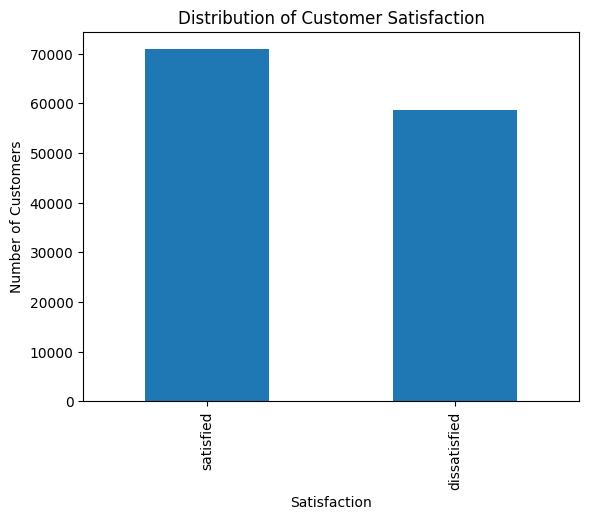

satisfaction,dissatisfied,satisfied
gender,,
Female,22904,42799
Male,35701,28083


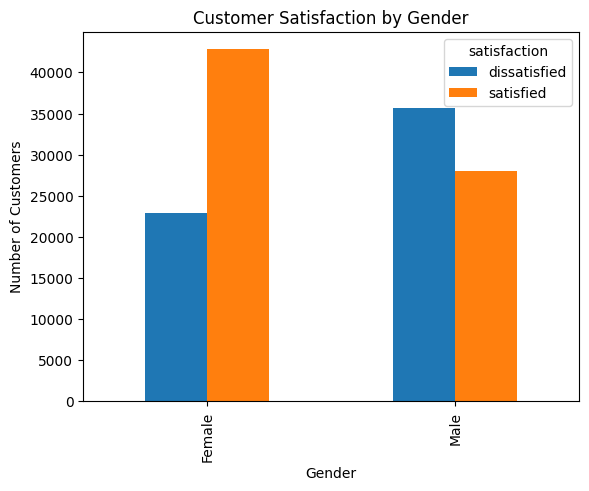

satisfaction,dissatisfied,satisfied
class,,
Business,18013,43977
Eco,35219,22898
Eco Plus,5373,4007


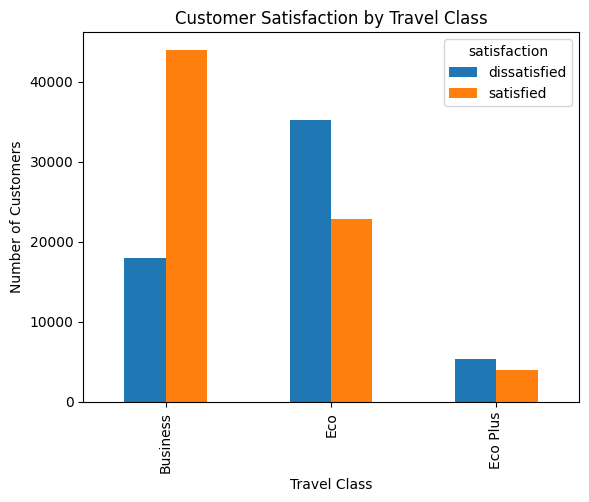

satisfaction,dissatisfied,satisfied
type_of_travel,,
Business travel,37238,52207
Personal Travel,21367,18675


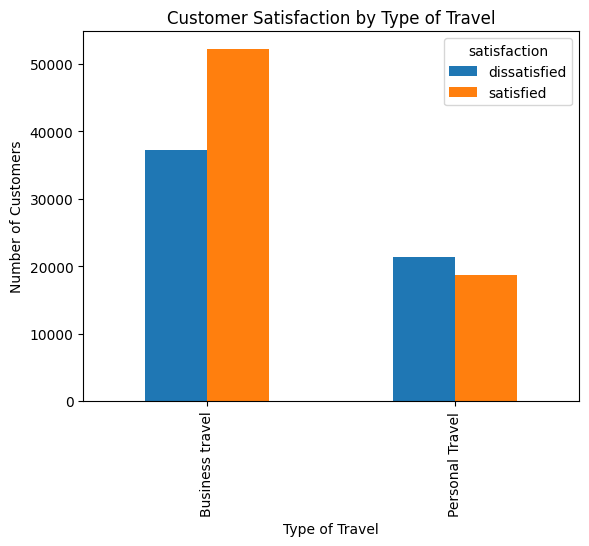

,total_delay
satisfaction,
dissatisfied,36.233376
satisfied,24.361276


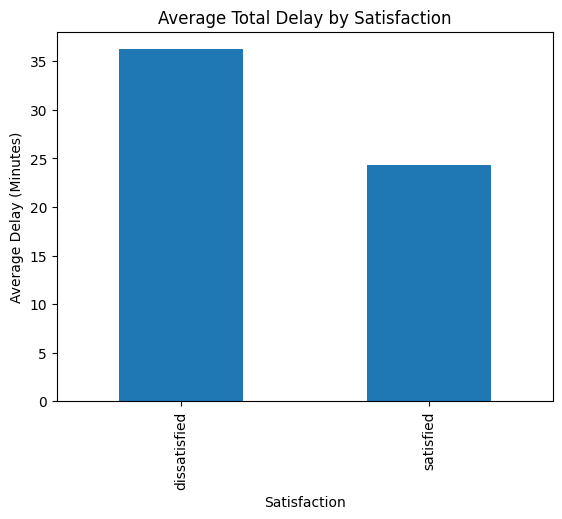

,age
satisfaction,
dissatisfied,37.468373
satisfied,41.049604


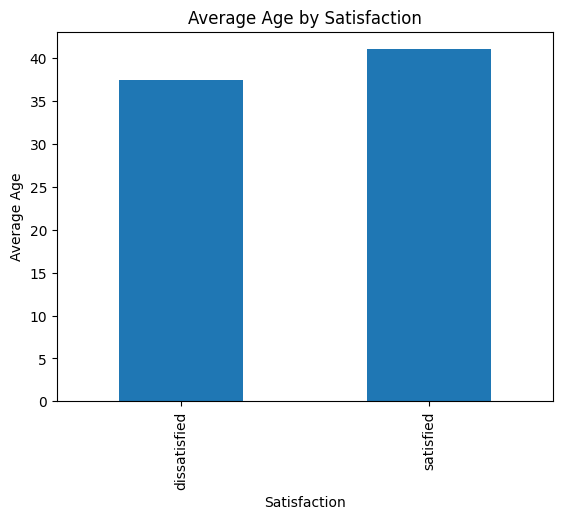

,0
cleanliness,3.705886
baggage_handling,3.695460
leg_room_service,3.486118
ease_of_online_booking,3.472171
on-board_service,3.465143
inflight_entertainment,3.383745
online_boarding,3.352545
checkin_service,3.340729
inflight_wifi_service,3.249160
gate_location,2.990377


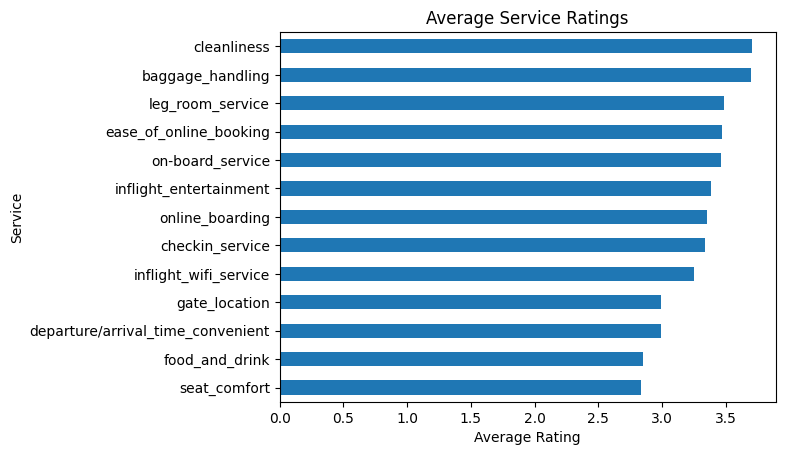

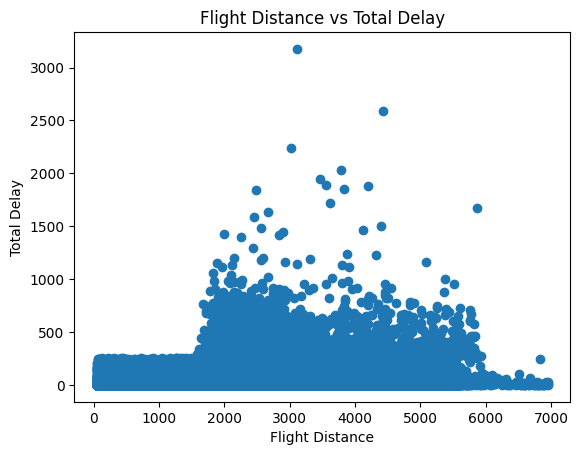

In [ ]:
#Data Visualisation
#Distribution of customer satisfaction
import pandas as pd

# Load the cleaned dataset
df = pd.read_csv("/content/Cleaned_Invistico_Airline (1).csv")

#Count customer satisfaction levels
analysis = df['satisfaction'].value_counts()
display(analysis)

import matplotlib.pyplot as plt
df['satisfaction'].value_counts().plot(kind='bar')
plt.title("Distribution of Customer Satisfaction")
plt.xlabel("Satisfaction")
plt.ylabel("Number of Customers")
plt.show()


#Does gender influence customer satisfaction?
analysis = pd.crosstab(df['gender'], df['satisfaction'])
display(analysis)
pd.crosstab(df['gender'], df['satisfaction']).plot(kind='bar')
plt.title("Customer Satisfaction by Gender")
plt.xlabel("Gender")
plt.ylabel("Number of Customers")
plt.show()

#Travel class with the highest customer satisfaction
analysis = pd.crosstab(df['class'], df['satisfaction'])
display(analysis)
pd.crosstab(df['class'], df['satisfaction']).plot(kind='bar')
plt.title("Customer Satisfaction by Travel Class")
plt.xlabel("Travel Class")
plt.ylabel("Number of Customers")
plt.show()

#Does the type of travel affect customer satisfaction?
analysis = pd.crosstab(df['type_of_travel'], df['satisfaction'])
display(analysis)
pd.crosstab(df['type_of_travel'], df['satisfaction']).plot(kind='bar')
plt.title("Customer Satisfaction by Type of Travel")
plt.xlabel("Type of Travel")
plt.ylabel("Number of Customers")
plt.show()

#How does total delay affect customer satisfaction?
analysis = df.groupby('satisfaction')['total_delay'].mean()
display(analysis)
df.groupby('satisfaction')['total_delay'].mean().plot(kind='bar')
plt.title("Average Total Delay by Satisfaction")
plt.xlabel("Satisfaction")
plt.ylabel("Average Delay (Minutes)")
plt.show()

#average age of satisfied and dissatisfied customers
analysis = df.groupby('satisfaction')['age'].mean()
display(analysis)
df.groupby('satisfaction')['age'].mean().plot(kind='bar')
plt.title("Average Age by Satisfaction")
plt.xlabel("Satisfaction")
plt.ylabel("Average Age")
plt.show()

#Which services receive the highest average ratings?
service_ratings = [
    'inflight_wifi_service',
    'departure/arrival_time_convenient',
    'ease_of_online_booking',
    'gate_location',
    'food_and_drink',
    'online_boarding',
    'seat_comfort',
    'inflight_entertainment',
    'on-board_service',
    'leg_room_service',
    'baggage_handling',
    'checkin_service',
    'cleanliness'
]

analysis = df[service_ratings].mean().sort_values(ascending=False)
display(analysis)
df[service_ratings].mean().sort_values().plot(kind='barh')
plt.title("Average Service Ratings")
plt.xlabel("Average Rating")
plt.ylabel("Service")
plt.show()

#Is there a relationship between flight distance and total delay?
plt.scatter(df['flight_distance'], df['total_delay'])
plt.title("Flight Distance vs Total Delay")
plt.xlabel("Flight Distance")
plt.ylabel("Total Delay")
plt.show()
